In [1]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('digit-recognizer')

print("Path to competition files:", path)

100%|██████████| 15.3M/15.3M [00:06<00:00, 2.31MB/s]

Extracting files...


Path to competition files: C:\Users\LENOVO\.cache\kagglehub\competitions\digit-recognizer


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import os
train_df = pd.read_csv(os.path.join(path, 'train.csv'))
test_df = pd.read_csv(os.path.join(path, 'test.csv'))
print(f"Train dataset shape: {train_df.shape}") 
print(f"Test dataset shape:  {test_df.shape}")

Train dataset shape: (42000, 785)
Test dataset shape:  (28000, 784)


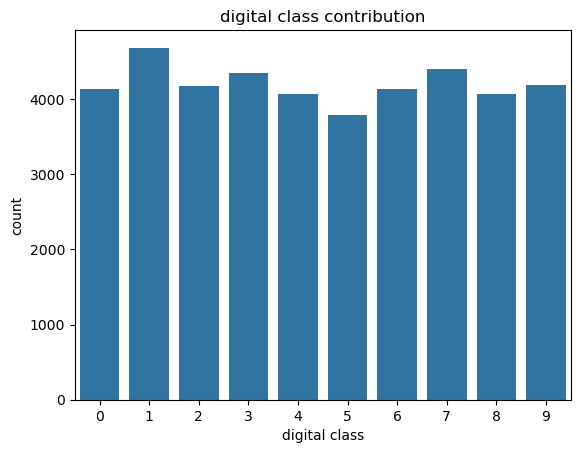

In [4]:
sns.countplot(x=train_df['label'])
plt.title("digital class contribution")
plt.xlabel("digital class")
plt.ylabel("count")
plt.show()

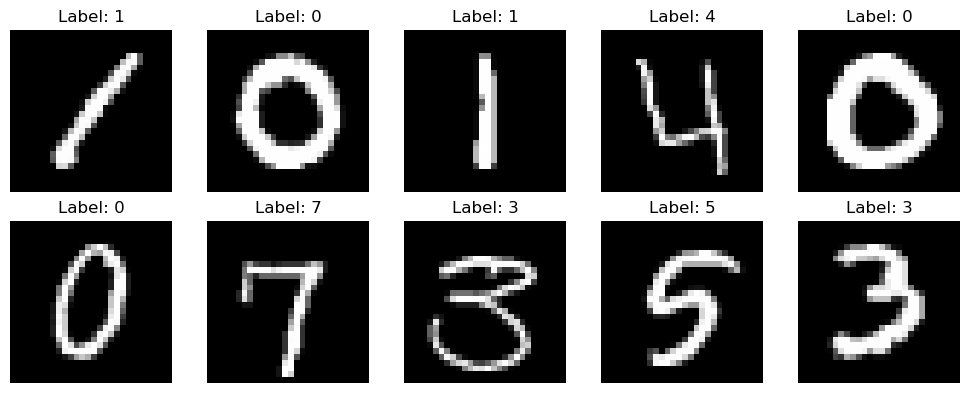

In [5]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    img = train_df.iloc[i, 1:].values.reshape(28, 28)
    label = train_df.iloc[i, 0]
    
    plt.imshow(img, cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [6]:
Y_raw = train_df['label'].values                   
X_raw = train_df.drop('label', axis=1).values      


X_normalized = X_raw / 255.0

val_size = int(len(X_normalized) * 0.2)

np.random.seed(42)
shuffled_indices = np.random.permutation(len(X_normalized))

val_indices = shuffled_indices[:val_size]
train_indices = shuffled_indices[val_size:]


X_train = X_normalized[train_indices].T            
Y_train = Y_raw[train_indices]                     

X_val = X_normalized[val_indices].T                
Y_val = Y_raw[val_indices]                         


X_test = (test_df.values / 255.0).T                 

print(f"X_train shape: {X_train.shape}, Y_train shape: {Y_train.shape}")
print(f"X_val shape:   {X_val.shape},   Y_val shape:   {Y_val.shape}")
print(f"X_test shape:  {X_test.shape}")

X_train shape: (784, 33600), Y_train shape: (33600,)
X_val shape:   (784, 8400),   Y_val shape:   (8400,)
X_test shape:  (784, 28000)


In [7]:
def one_hot(Y, num_classes=10):
    
    m = Y.size
    one_hot_Y = np.zeros((num_classes, m))
    one_hot_Y[Y, np.arange(m)] = 1
    return one_hot_Y


Y_train_encoded = one_hot(Y_train)
print(f"One-hot encoded Y_train shape: {Y_train_encoded.shape}")

One-hot encoded Y_train shape: (10, 33600)


In [8]:
def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    return (Z > 0).astype(float)

def softmax(Z):
    exp_Z = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return exp_Z / np.sum(exp_Z, axis=0, keepdims=True)

In [9]:
def initialize_parameters(layer_dims):
    
    np.random.seed(42)
    parameters = {}
    L = len(layer_dims) 
    
    for l in range(1, L):
        
        parameters[f'W{l}'] = np.random.randn(layer_dims[l], layer_dims[l-1]) * np.sqrt(2.0 / layer_dims[l-1])
        parameters[f'b{l}'] = np.zeros((layer_dims[l], 1))
        
    return parameters

In [10]:
def forward_propagation(X, parameters):
    cache = {'A0': X}
    
    Z1 = np.dot(parameters['W1'], X) + parameters['b1']
    A1 = relu(Z1)
    cache['Z1'], cache['A1'] = Z1, A1
    
    Z2 = np.dot(parameters['W2'], A1) + parameters['b2']
    A2 = softmax(Z2)
    cache['Z2'], cache['A2'] = Z2, A2
    
    return A2, cache

In [11]:
def compute_loss(A2, Y_one_hot):
    m = Y_one_hot.shape[1]
    
    loss = - (1 / m) * np.sum(Y_one_hot * np.log(A2 + 1e-15))
    return loss

In [12]:
def backward_propagation(parameters, cache, Y_one_hot):
   
    m = Y_one_hot.shape[1] 
    
    
    A0 = cache['A0'] 
    Z1 = cache['Z1']
    A1 = cache['A1'] 
    A2 = cache['A2'] 
    
    W2 = parameters['W2']
    
   
    dZ2 = A2 - Y_one_hot                                      
    dW2 = (1.0 / m) * np.dot(dZ2, A1.T)                      
    db2 = (1.0 / m) * np.sum(dZ2, axis=1, keepdims=True)      
    
    
    dA1 = np.dot(W2.T, dZ2)                                   
    dZ1 = dA1 * relu_derivative(Z1)                           
    dW1 = (1.0 / m) * np.dot(dZ1, A0.T)                       
    db1 = (1.0 / m) * np.sum(dZ1, axis=1, keepdims=True)      
    
    gradients = {
        'dW1': dW1, 'db1': db1,
        'dW2': dW2, 'db2': db2
    }
    
    return gradients

In [13]:
def update_parameters(parameters, gradients, learning_rate):
   
    parameters['W1'] -= learning_rate * gradients['dW1']
    parameters['b1'] -= learning_rate * gradients['db1']
    parameters['W2'] -= learning_rate * gradients['dW2']
    parameters['b2'] -= learning_rate * gradients['db2']
    
    return parameters

In [14]:
def get_predictions(A2):
   
    return np.argmax(A2, axis=0)

def compute_accuracy(y_pred, y_true):
    return np.mean(y_pred == y_true) * 100.0

In [15]:
def train_model(X_train, Y_train, X_val, Y_val, layer_dims, epochs=20, batch_size=64, learning_rate=0.1):
    
    parameters = initialize_parameters(layer_dims)
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [],  'val_acc': []
    }
    
    m_train = X_train.shape[1]
    
    for epoch in range(1, epochs + 1):
        
        permutation = np.random.permutation(m_train)
        X_shuffled = X_train[:, permutation]
        Y_shuffled = Y_train[permutation]
        
        
        num_batches = int(np.ceil(m_train / batch_size))
        
        for b in range(num_batches):
            start_idx = b * batch_size
            end_idx = min(start_idx + batch_size, m_train)
            
            X_batch = X_shuffled[:, start_idx:end_idx]
            Y_batch = Y_shuffled[start_idx:end_idx]
            Y_batch_encoded = one_hot(Y_batch)
            
            
            A2_batch, cache = forward_propagation(X_batch, parameters)
            
            
            grads = backward_propagation(parameters, cache, Y_batch_encoded)
            
           
            parameters = update_parameters(parameters, grads, learning_rate)
            
        
        Y_train_encoded = one_hot(Y_train)
        Y_val_encoded = one_hot(Y_val)
        
        A2_train, _ = forward_propagation(X_train, parameters)
        A2_val, _   = forward_propagation(X_val, parameters)
        
        loss_tr = compute_loss(A2_train, Y_train_encoded)
        loss_va = compute_loss(A2_val, Y_val_encoded)
        
        acc_tr = compute_accuracy(get_predictions(A2_train), Y_train)
        acc_va = compute_accuracy(get_predictions(A2_val), Y_val)
        
        history['train_loss'].append(loss_tr)
        history['val_loss'].append(loss_va)
        history['train_acc'].append(acc_tr)
        history['val_acc'].append(acc_va)
        
        print(f"Epoch {epoch:02d}/{epochs} - Train Loss: {loss_tr:.4f} - Train Acc: {acc_tr:.2f}% | Val Loss: {loss_va:.4f} - Val Acc: {acc_va:.2f}%")
        
    return parameters, history

In [16]:
layer_dims = [784, 128, 10]


baseline_params, baseline_history = train_model(
    X_train, Y_train, X_val, Y_val,
    layer_dims=layer_dims,
    epochs=15,
    batch_size=64,
    learning_rate=0.1
)

Epoch 01/15 - Train Loss: 0.2739 - Train Acc: 92.28% | Val Loss: 0.2942 - Val Acc: 91.69%
Epoch 02/15 - Train Loss: 0.2073 - Train Acc: 94.10% | Val Loss: 0.2310 - Val Acc: 93.54%
Epoch 03/15 - Train Loss: 0.1697 - Train Acc: 95.16% | Val Loss: 0.1977 - Val Acc: 94.15%
Epoch 04/15 - Train Loss: 0.1517 - Train Acc: 95.60% | Val Loss: 0.1829 - Val Acc: 94.58%
Epoch 05/15 - Train Loss: 0.1213 - Train Acc: 96.61% | Val Loss: 0.1580 - Val Acc: 95.39%
Epoch 06/15 - Train Loss: 0.1078 - Train Acc: 97.06% | Val Loss: 0.1491 - Val Acc: 95.67%
Epoch 07/15 - Train Loss: 0.0968 - Train Acc: 97.32% | Val Loss: 0.1391 - Val Acc: 96.01%
Epoch 08/15 - Train Loss: 0.0837 - Train Acc: 97.76% | Val Loss: 0.1288 - Val Acc: 96.36%
Epoch 09/15 - Train Loss: 0.0819 - Train Acc: 97.77% | Val Loss: 0.1295 - Val Acc: 96.11%
Epoch 10/15 - Train Loss: 0.0690 - Train Acc: 98.32% | Val Loss: 0.1182 - Val Acc: 96.55%
Epoch 11/15 - Train Loss: 0.0625 - Train Acc: 98.41% | Val Loss: 0.1148 - Val Acc: 96.70%
Epoch 12/1

In [17]:
print("Experiment 1: Baseline")
params_exp1, hist_exp1 = train_model(
    X_train, Y_train, X_val, Y_val,
    layer_dims=[784, 128, 10], epochs=15, batch_size=64, learning_rate=0.1
)


print("\nExperiment 2: LR=0.01, Batch=32")
params_exp2, hist_exp2 = train_model(
    X_train, Y_train, X_val, Y_val,
    layer_dims=[784, 64, 10], epochs=15, batch_size=32, learning_rate=0.01
)


print("\nExperiment 3: Wider Network (256 units) ---")
params_exp3, hist_exp3 = train_model(
    X_train, Y_train, X_val, Y_val,
    layer_dims=[784, 256, 10], epochs=15, batch_size=64, learning_rate=0.1
)

Experiment 1: Baseline
Epoch 01/15 - Train Loss: 0.2739 - Train Acc: 92.28% | Val Loss: 0.2942 - Val Acc: 91.69%
Epoch 02/15 - Train Loss: 0.2073 - Train Acc: 94.10% | Val Loss: 0.2310 - Val Acc: 93.54%
Epoch 03/15 - Train Loss: 0.1697 - Train Acc: 95.16% | Val Loss: 0.1977 - Val Acc: 94.15%
Epoch 04/15 - Train Loss: 0.1517 - Train Acc: 95.60% | Val Loss: 0.1829 - Val Acc: 94.58%
Epoch 05/15 - Train Loss: 0.1213 - Train Acc: 96.61% | Val Loss: 0.1580 - Val Acc: 95.39%
Epoch 06/15 - Train Loss: 0.1078 - Train Acc: 97.06% | Val Loss: 0.1491 - Val Acc: 95.67%
Epoch 07/15 - Train Loss: 0.0968 - Train Acc: 97.32% | Val Loss: 0.1391 - Val Acc: 96.01%
Epoch 08/15 - Train Loss: 0.0837 - Train Acc: 97.76% | Val Loss: 0.1288 - Val Acc: 96.36%
Epoch 09/15 - Train Loss: 0.0819 - Train Acc: 97.77% | Val Loss: 0.1295 - Val Acc: 96.11%
Epoch 10/15 - Train Loss: 0.0690 - Train Acc: 98.32% | Val Loss: 0.1182 - Val Acc: 96.55%
Epoch 11/15 - Train Loss: 0.0625 - Train Acc: 98.41% | Val Loss: 0.1148 - Val

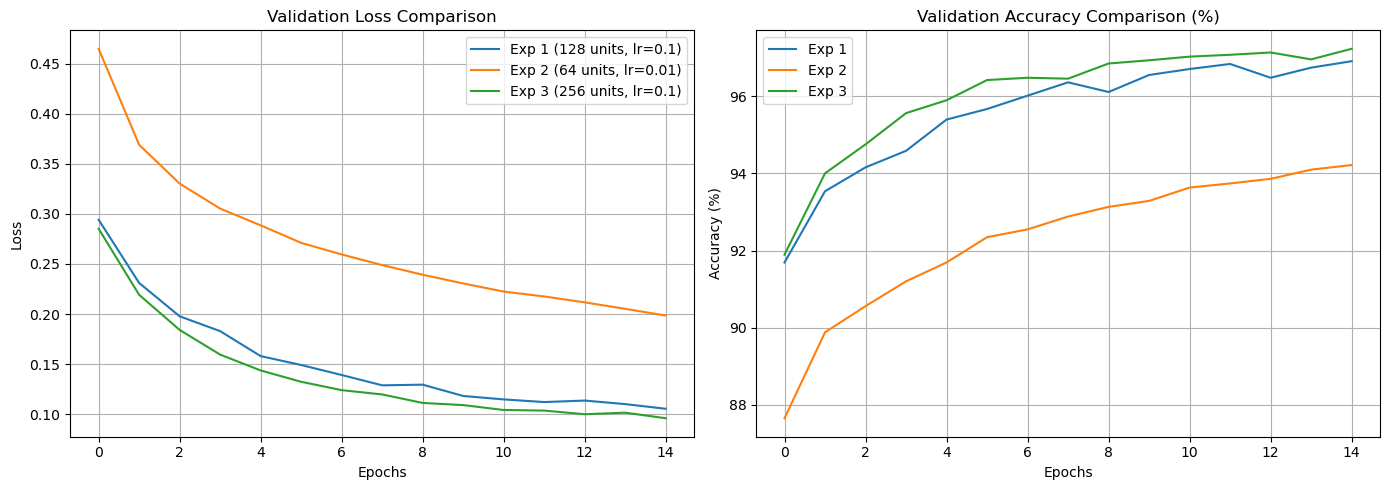

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss Plot
axes[0].plot(hist_exp1['val_loss'], label='Exp 1 (128 units, lr=0.1)')
axes[0].plot(hist_exp2['val_loss'], label='Exp 2 (64 units, lr=0.01)')
axes[0].plot(hist_exp3['val_loss'], label='Exp 3 (256 units, lr=0.1)')
axes[0].set_title('Validation Loss Comparison')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy Plot
axes[1].plot(hist_exp1['val_acc'], label='Exp 1')
axes[1].plot(hist_exp2['val_acc'], label='Exp 2')
axes[1].plot(hist_exp3['val_acc'], label='Exp 3')
axes[1].set_title('Validation Accuracy Comparison (%)')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Classification Report:

              precision    recall  f1-score   support

           0     0.9676    0.9890    0.9782       816
           1     0.9720    0.9912    0.9815       909
           2     0.9866    0.9563    0.9712       846
           3     0.9707    0.9552    0.9629       937
           4     0.9636    0.9774    0.9704       839
           5     0.9430    0.9658    0.9543       702
           6     0.9783    0.9771    0.9777       785
           7     0.9784    0.9642    0.9712       893
           8     0.9755    0.9533    0.9643       835
           9     0.9516    0.9618    0.9567       838

    accuracy                         0.9690      8400
   macro avg     0.9687    0.9691    0.9688      8400
weighted avg     0.9692    0.9690    0.9690      8400



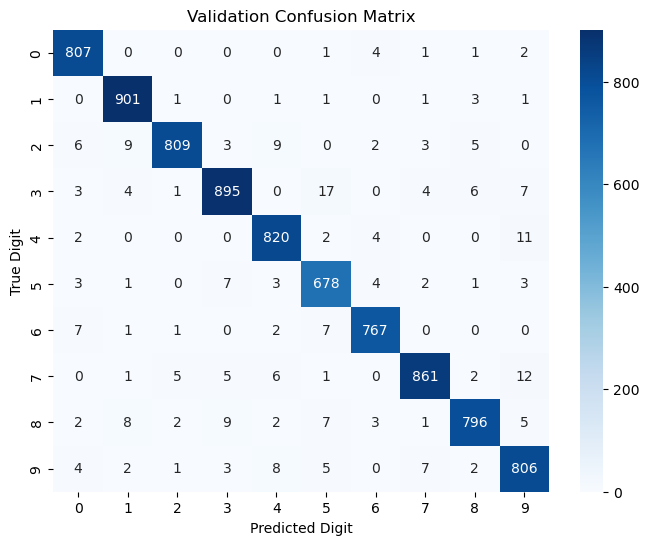

In [19]:
from sklearn.metrics import classification_report, confusion_matrix


A2_val_best, _ = forward_propagation(X_val, params_exp1)
val_preds = get_predictions(A2_val_best)


print("Classification Report:\n")
print(classification_report(Y_val, val_preds, digits=4))


cm = confusion_matrix(Y_val, val_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title('Validation Confusion Matrix')
plt.xlabel('Predicted Digit')
plt.ylabel('True Digit')
plt.show()

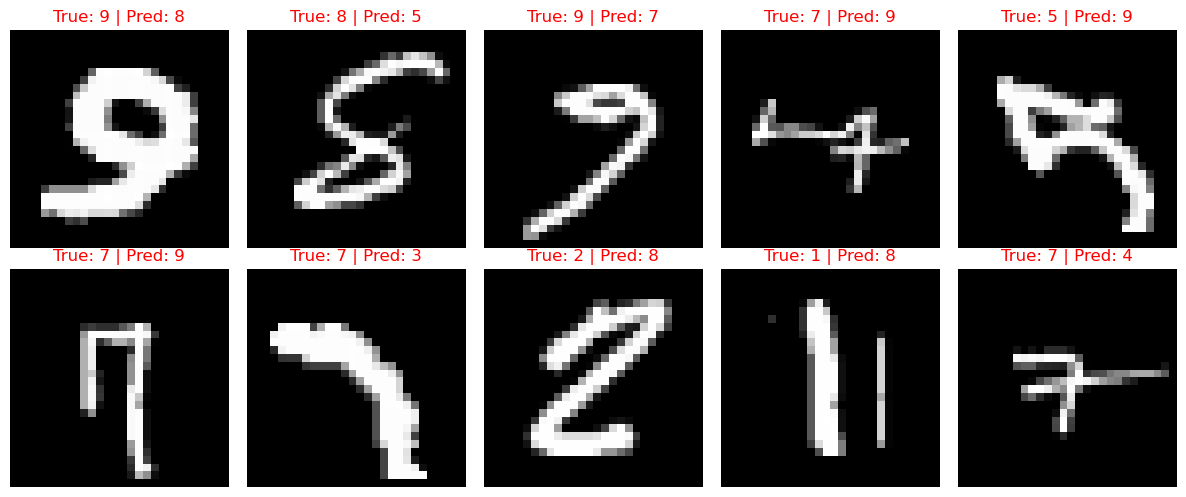

In [20]:

misclassified_idx = np.where(val_preds != Y_val)[0]

plt.figure(figsize=(12, 5))
for i, idx in enumerate(misclassified_idx[:10]):
    plt.subplot(2, 5, i + 1)
    img = X_val[:, idx].reshape(28, 28)
    true_label = Y_val[idx]
    pred_label = val_preds[idx]
    
    plt.imshow(img, cmap='gray')
    plt.title(f"True: {true_label} | Pred: {pred_label}", color='red')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
A2_test, _ = forward_propagation(X_test, params_exp1)
test_preds = get_predictions(A2_test)


submission_df = pd.DataFrame({
    'ImageId': np.arange(1, len(test_preds) + 1),
    'Label': test_preds
})

# Save to CSV
submission_df.to_csv('submission.csv', index=False)
print("Submission file successfully generated: submission.csv")
print(submission_df.head())